# **The Goal of This Project**

The PDF file doesn't express the goal of the project clearly. We restate it here:

We observed historical 1-minute futures OHLCV data. We can resample it into x-minute data as long as x divides 60. For a chosen horizon $\tau=5,10,\dots$, we estimate the empirical distribution of future upward and downward price excursions, either unconditionally or conditional on the current volatility-volume-trend regime. These distributions are then used to determine where to place limit orders, so as to maximize expected execution quality by balancing fill probability against price improvement. The resulting rule is then backtested and compared with a benchmark, such as the reconstructed PnL of the market maker from the "AIAgent_xxx" files.

At time $t$, let the current reference price (open price) be $x_t$ and the tick size be $\epsilon$

If we want to buy, candidiate limit prices are:
$$
p_k^{buy}=x_t-k\epsilon, \quad k=0,1,2,\dots
$$

If we want to sell, candidiate limit prices are:
$$
p_k^{sell}=x_t+k\epsilon, \quad k=0,1,2,\dots
$$

Here $k$ is the aggressiveness/passiveness choice:

- small $k$: closer to market, easier fill, worse price

- large $k$: better price, lower fill probability.


For a buy order at $x_t-k\epsilon$, you get filled if the future low falls at least $k$ ticks below the open,
$$
R_{t,\tau}^{(D)} \ge k \epsilon
$$

So,
$$
P(\text{buy fill at k})=P\left( R_{t,\tau}^{(D)} \ge k\epsilon \mid \text{state}_t \right)
$$

Similarly, for a sell order at $x_t+k\epsilon$,
$$
P(\text{sell fill at k})=P\left( R_{t,\tau}^{(U)} \ge k\epsilon \mid \text{state}_t \right)
$$

If unconditional:
$$
P(\text{buy fill at k})=P\left( R_{t,\tau}^{(D)} \ge k\epsilon \right)
$$
$$
P(\text{sell fill at k})=P\left( R_{t,\tau}^{(U)} \ge k\epsilon \right)
$$


Now we need to determine how to choose $k$. Before proceeding, note an implicit assumption above: **we don't split orders.**

For example, during the interval $[t, t+\tau)$, suppose we want to sell 5 units. The above method places all 5 units at a single price level $p_k^{sell}$. Alternatively, we could split the order across multiple levels (e.g. 2 units at $p_{k-1}^{sell}$, 2 units at $p_{k}^{sell}$, and 1 units at $p_{k+1}^{sell}$).

Since the second approach is significantly more complex, we focus on the first case: no order splitting.

We have more flexibility than the agent. At time $t$, whenever there is buy/sell demand, the agent immediately executes at the market price $p_t$. In constrast, we can decide whether to trade now or hold the demand and trade later, or we can submit limite orders based on fill probabilities, and there is no penalty for unexecuted orders accumulating over time.

This leads to the following execution dynamics:

- If we want to sell at $p_k^{sell}$, but $R_{t,\tau}^{(D)}<k$, the order is not filled and is carried forward to the next interval.

- If we want to buy at $p_k^{buy}$, but $R_{t,\tau}^{(U)}<k$, the order is not filled and is carried forward to the next interval.

Therefore,the expected cash flow over the interval $[t,t+\tau)$ is
$$
\text{buy q units}: \quad - \sum_{i=1}^{n_t} \left[ P\left( R_{t,\tau}^{(D)} \ge k_i\epsilon \mid \text{state}_t \right) p_{k_i}^{buy}  \right] q_i
$$
$$
\text{sell q units}: \quad \sum_{i=1}^{n_t} \left[ P\left( R_{t,\tau}^{(U)} \ge k_i\epsilon \mid \text{state}_t \right) p_{k_i}^{sell}  \right] q_i
$$

where $q_i$ denotes the accumulated (unexecuted) order size, $n_t \ge 0$ denotes the number of accumulated unexecuted orders at time $t$.

# **Trading Rules (How to choose $k$)**

I asked ChatGPT and it gave me so many rules, some of them are listed below:

## **Rule 1: Fill-probability threshold**

Suppose we already know we want to but.

For each $k$, compute
$$
P_k^{buy}=P(R_{t,\tau}^{(D)}\ge k\epsilon \mid \text{state}_t)
$$

The choose the deepest level satisfying
$$
P_k^{buy} \ge p^*
$$
for some threshold like $p^*=0.8,0.9$.

## **Rule 2: Expected-price-improvement rule**

For each $k$, define
$$
\text{score}_k^{buy}=P_k^{buy} \cdot k\epsilon
$$
$$
\text{score}_k^{sell}=P_k^{sell} \cdot k\epsilon
$$

choose $k$ that maximizes the score.

This treats $k$ as the price improvement, weighted by fill probability.

## **Rule 3: Expected PnL rule**

Estimate, from historical data in the same state:

- probability of fill at level $k$

- average terminal move after such a fill $p_k^{sell}-x_{t+1}$ for sell and $x_{t+1}-p_k^{buy}$ for buy

Then choose $k$ maximizing expected PnL net of costs:
$$
\text{EV}_k = P(\text{fill}_k) \times \text{Avg payoff after fill}_k - \text{fees/slippage}
$$

There are many other trading rules, but for this project, I will choose the first rule because it's the simplest one. For me who is a beginner of order management, it's a good starting point.

But I have one question: why we focus on filling probability? If we want to improve the PnL of a trading strategy, why not just adjust the price at which we place our order? For example, if we want to sell a order, why not just choose the price $p_t + \epsilon$? If this is executed, we will earn $\epsilon$ more! If we do this for every order, we will definitely earn more money.

But this is not that simple. In the above example, there is possibility that the price doesn't reach the target price and the order is not executed. There are at least three methods to cope with this case: don't change the order price, change the order price based on the latest price, immediately execute on the current price using a market order.

Our ideal assumption meets the first method: in the future there will be a price that reach the original targeted price and our order is executed. But other case is that the price will never be reached and our order will always not be executed.

For the second situation, we are not sure the relationship between these two prices, if the latter price is lower, even if our order is executed on the new target price, this price may still be lower than the original price, which means we face a loss.

For the third situation, it's very similar to the problem of the second situion, we don't know the relationship between these two prices, which will result in loss.

Now we will use code to testify my thinking. There are $7$ assets, and different assets behave differently. But I can't try every idea on all $7$ assets. I will choose "**Nasdaq**" as a reprensentitve asset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path
import re

import warnings
warnings.filterwarnings

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR
from src.trade.intuition_rule import agent_rule,ideal_rule,tick_fixed,tick_reset,tick_close,tick_prev_close
from src.trade.intuition_rule import compute_stats

In [3]:
futures_path=DATA_DIR/'futures_right'
agent_path=DATA_DIR/'agent_right'
market='Nasdaq'

data1=pd.read_parquet(futures_path/'minute_1'/f'{market}.parquet').reset_index(drop=True)
data1_prep=pd.read_parquet(futures_path/'minute_1'/f'{market}_prep.parquet').reset_index(drop=True)
data5=pd.read_parquet(futures_path/'minute_5'/f'{market}.parquet').reset_index(drop=True)
data5_prep=pd.read_parquet(futures_path/'minute_5'/f'{market}_prep.parquet').reset_index(drop=True)
agent_data=pd.read_parquet(agent_path/f'{market}.parquet').reset_index(drop=True)
trading_data=data5[['time','open','high','low','close','volume']].merge(agent_data[['time','price','position']],on='time').reset_index(drop=True)

trading_data.head()

,time,open,high,low,close,volume,price,position
0,2020-01-02 06:00:00,8787.25,8788.00,8787.25,8787.75,77.0,8787.75,0
1,2020-01-02 06:05:00,8787.75,8788.25,8787.25,8787.75,98.0,8787.75,0
2,2020-01-02 06:10:00,8787.75,8787.75,8786.00,8786.00,120.0,8786.00,0
3,2020-01-02 06:15:00,8786.00,8786.75,8785.50,8785.50,170.0,8785.50,0
4,2020-01-02 06:20:00,8785.50,8786.75,8784.50,8785.25,154.0,8785.25,0


In [4]:
tau = 10
k = 1
tick_size = 0.25

agent_pnl, agent_exec = agent_rule(trading_data)
ideal_pnl, ideal_exec = ideal_rule(trading_data, tau=tau)

reset_pnl, reset_exec = tick_reset(trading_data, tau=tau, k=k, tick_size=tick_size)
fixed_pnl, fixed_exec = tick_fixed(trading_data, tau=tau, k=k, tick_size=tick_size)
close_pnl, close_exec = tick_close(trading_data, tau=tau, k=k, tick_size=tick_size)
prev_close_pnl, prev_close_exec = tick_prev_close(trading_data, tau=tau, k=k, tick_size=tick_size)

stats = {
    "agent": compute_stats(agent_pnl),
    "ideal": compute_stats(ideal_pnl),
    "tick_reset": compute_stats(reset_pnl),
    "tick_fixed": compute_stats(fixed_pnl),
    "tick_close": compute_stats(close_pnl),
    "tick_prev_close": compute_stats(prev_close_pnl),
}

for key, series in stats.items():
    print(f'======== {key} ========')
    print(series)
    print()

======== agent ========
{'start_time': Timestamp('2020-01-02 06:00:00'), 'end_time': Timestamp('2020-06-01 05:55:00'), 'total_return': np.float64(28950.25), 'max_drawdown': np.float64(-6277.5), 'sharpe': np.float64(4.146708102675155)}

======== ideal ========
{'start_time': Timestamp('2020-01-02 06:00:00'), 'end_time': Timestamp('2020-06-01 05:55:00'), 'total_return': np.float64(146724.0), 'max_drawdown': np.float64(-2824.0), 'sharpe': np.float64(20.367637206961767)}

======== tick_reset ========
{'start_time': Timestamp('2020-01-02 06:00:00'), 'end_time': Timestamp('2020-06-01 05:55:00'), 'total_return': np.float64(26485.25), 'max_drawdown': np.float64(-6548.25), 'sharpe': np.float64(3.7992373381845694)}

======== tick_fixed ========
{'start_time': Timestamp('2020-01-02 06:00:00'), 'end_time': Timestamp('2020-06-01 05:55:00'), 'total_return': np.float64(30870.75), 'max_drawdown': np.float64(-12198.75), 'sharpe': np.float64(3.0986799196362984)}

======== tick_close ========
{'start_tim

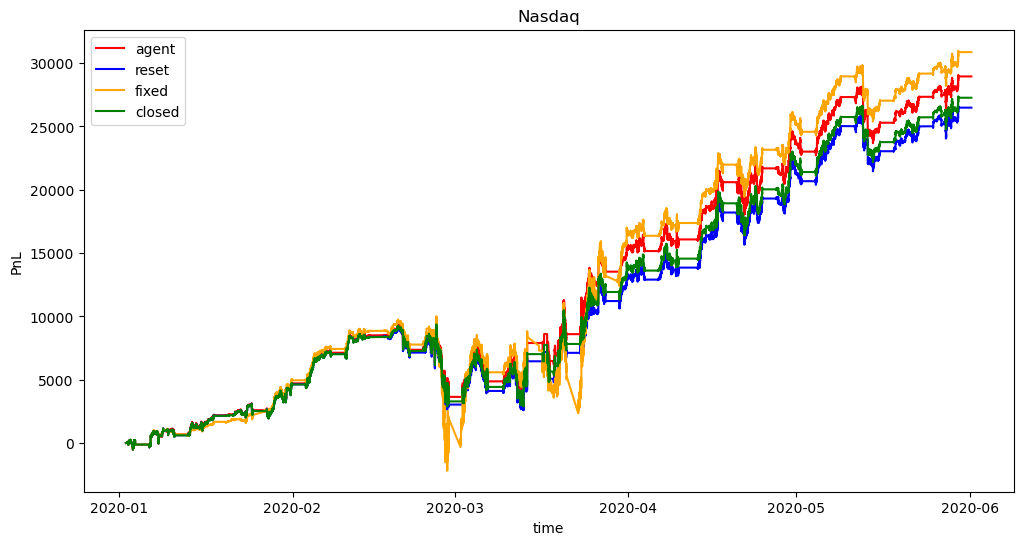

In [5]:
plt.figure(figsize=(12,6))
plt.plot(agent_pnl['time'],agent_pnl['pnl'],label='agent',color='red')
plt.plot(reset_pnl['time'],reset_pnl['pnl'],label='reset',color='blue')
plt.plot(fixed_pnl['time'],fixed_pnl['pnl'],label='fixed',color='orange')
plt.plot(close_pnl['time'],close_pnl['pnl'],label='closed',color='green')
plt.xlabel('time')
plt.ylabel('PnL')
plt.title(f'{market}')
plt.legend()
plt.show()

The result is quite aligned with my thinking:

- "fixed" means if the order is not executed in the first $\tau$-interval, we don't change the price, we continue to place the order at that price. It achieves the largest PnL but also have largest drawdown, and its Sharpe Ratio is the lowest.

- "reset" means if the order is not executed in the first $\tau$-interval, we change the price based on the latest price. Its PnL and Sharpe Ratio is a bit lower than the agent's. My former assumptions are exactly the reason.

- "closed" means if the order is not executed in the first $\tau$-interval,  we immediately executed at the latest price. This is closet to practical needs because we often require orders should be executed with certain time.

In [6]:
print('======== fixed ========')
filling_p=round(1-(fixed_exec['placed_prices'].apply(len)>1).sum()/len(fixed_exec),4)
placed_times=(fixed_exec['placed_prices'].apply(len).sum()-len(fixed_exec))/(fixed_exec['placed_prices'].apply(len)>1).sum()+1
placed_times=round(placed_times,2)
temp=fixed_exec[['signal_time','side','exec_price']].merge(agent_exec[['signal_time','exec_price']],on='signal_time')
temp["better"] = (
    ((temp["side"] == "buy") & (temp["exec_price_x"] < temp["exec_price_y"])) |
    ((temp["side"] == "sell") & (temp["exec_price_x"] > temp["exec_price_y"]))
).astype(int)
better_p=round(temp['better'].sum()/len(temp),4)

print(f'filling_p: {filling_p}')
print(f'placed_times: {placed_times}')
print(f'better_p: {better_p}')
print()


print('======== reset ========')
filling_p=round(1-(reset_exec['placed_prices'].apply(len)>1).sum()/len(reset_exec),4)
placed_times=(reset_exec['placed_prices'].apply(len).sum()-len(reset_exec))/(reset_exec['placed_prices'].apply(len)>1).sum()+1
placed_times=round(placed_times,2)
temp=reset_exec[['signal_time','side','exec_price']].merge(agent_exec[['signal_time','exec_price']],on='signal_time')
temp["better"] = (
    ((temp["side"] == "buy") & (temp["exec_price_x"] < temp["exec_price_y"])) |
    ((temp["side"] == "sell") & (temp["exec_price_x"] > temp["exec_price_y"]))
).astype(int)
better_p=round(temp['better'].sum()/len(temp),4)

print(f'filling_p: {filling_p}')
print(f'placed_times: {placed_times}')
print(f'better_p: {better_p}')
print()

print('======== closed ========')
filling_p=round(1-(close_exec['placed_prices'].apply(len)>1).sum()/len(close_exec),4)
placed_times=(close_exec['placed_prices'].apply(len).sum()-len(close_exec))/(close_exec['placed_prices'].apply(len)>1).sum()+1
placed_times=round(placed_times,2)
temp=close_exec[['signal_time','side','exec_price']].merge(agent_exec[['signal_time','exec_price']],on='signal_time')
temp["better"] = (
    ((temp["side"] == "buy") & (temp["exec_price_x"] < temp["exec_price_y"])) |
    ((temp["side"] == "sell") & (temp["exec_price_x"] > temp["exec_price_y"]))
).astype(int)
better_p=round(temp['better'].sum()/len(temp),4)

print(f'filling_p: {filling_p}')
print(f'placed_times: {placed_times}')
print(f'better_p: {better_p}')
print()

======== fixed ========
filling_p: 0.963
placed_times: 60.78
better_p: 1.0

======== reset ========
filling_p: 0.963
placed_times: 3.78
better_p: 0.9727

======== closed ========
filling_p: 0.963
placed_times: 2.0
better_p: 0.963

